In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install kmodes

In [ ]:
!pip install kneed

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from kneed import KneeLocator
from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes

In [ ]:
df_raw = pd.read_csv("/content/drive/MyDrive/segmentation data.csv", sep = ";")
df_raw

,USER,NAMA_LAYANAN,KELURAHAN,SUBMITED_AT[TGL_TERBIT_KITIR],ASAL,JENIS_KELAMIN,USIA,PEKERJAAN,PENDIDIKAN
0,Abo***,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,SIDOTOPO WETAN (1002),21/06/2024 09:04,Warga,PEREMPUAN,23.0,PELAJAR/MAHASISWA,BELUM TAMAT SD/SEDERAJAT
1,Dia***********,Akta Kelahiran Sudah Memiliki NIK Anak Ayah da...,TEGALSARI (1001),21/06/2024 09:08,Warga,PEREMPUAN,26.0,PELAJAR/MAHASISWA,SLTP/SEDERAJAT
2,357*************,Keabsahan Akta Kelahiran (Pemilik dokumen SURA...,RANGKAH (1005),21/06/2024 08:57,Warga,PEREMPUAN,56.0,WIRASWASTA,SLTP/SEDERAJAT
3,Gig**,Pemutakhiran Biodata,Simomulyo (1005),21/06/2024 08:33,Warga,LAKI-LAKI,21.0,BELUM/TIDAK BEKERJA,SLTP/SEDERAJAT
4,TOI**,Pindah Keluar Anggota Keluarga,SIDOTOPO (1005),21/06/2024 08:21,Warga,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
16400,Mas*****,Legalisir Akta Kelahiran (Pemilik dokumen SURA...,Pegirian (1002),07/12/2024 11:24,Warga,LAKI-LAKI,47.0,KARYAWAN SWASTA,SLTA/SEDERAJAT
16401,lan***********,Pindah Keluar Seluruh Anggota KK,KEBONSARI (1003),07/12/2024 11:21,Warga,NaN,NaN,NaN,NaN
16402,Mas*****,Legalisir Akta Kelahiran (Pemilik dokumen SURA...,Pegirian (1002),07/12/2024 11:10,Warga,LAKI-LAKI,47.0,KARYAWAN SWASTA,SLTA/SEDERAJAT
16403,gho*******,Pemutakhiran Biodata,SAWUNGGALING (1006),07/12/2024 11:49,Warga,PEREMPUAN,31.0,KARYAWAN SWASTA,AKADEMI/DIPLOMA III/SARJANA MUDA


## DATA PREPROCESSING

In [ ]:
# Hapus kolom
df = df_raw.copy()
df = df.drop(columns = ['ASAL', 'USER', 'SUBMITED_AT[TGL_TERBIT_KITIR]'])
# Rename kolom
df = df.rename(columns = {'NAMA_LAYANAN': 'NAMA LAYANAN', 'JENIS_KELAMIN': 'JENIS KELAMIN'})
# Memperbaiki isi kolom 'KELURAHAN'
df['KELURAHAN'] = df['KELURAHAN'].str.title()
df.head()

,NAMA LAYANAN,KELURAHAN,JENIS KELAMIN,USIA,PEKERJAAN,PENDIDIKAN
0,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Sidotopo Wetan (1002),PEREMPUAN,23.0,PELAJAR/MAHASISWA,BELUM TAMAT SD/SEDERAJAT
1,Akta Kelahiran Sudah Memiliki NIK Anak Ayah da...,Tegalsari (1001),PEREMPUAN,26.0,PELAJAR/MAHASISWA,SLTP/SEDERAJAT
2,Keabsahan Akta Kelahiran (Pemilik dokumen SURA...,Rangkah (1005),PEREMPUAN,56.0,WIRASWASTA,SLTP/SEDERAJAT
3,Pemutakhiran Biodata,Simomulyo (1005),LAKI-LAKI,21.0,BELUM/TIDAK BEKERJA,SLTP/SEDERAJAT
4,Pindah Keluar Anggota Keluarga,Sidotopo (1005),NaN,NaN,NaN,NaN


In [ ]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16405 entries, 0 to 16404
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NAMA LAYANAN   16405 non-null  object 
 1   KELURAHAN      16405 non-null  object 
 2   JENIS KELAMIN  14076 non-null  object 
 3   USIA           14076 non-null  float64
 4   PEKERJAAN      14075 non-null  object 
 5   PENDIDIKAN     14075 non-null  object 
dtypes: float64(1), object(5)
memory usage: 769.1+ KB


In [ ]:
# Cek missing values
missing_values = df.isnull().sum()
print(missing_values)

NAMA LAYANAN        0
KELURAHAN           0
JENIS KELAMIN    2329
USIA             2329
PEKERJAAN        2330
PENDIDIKAN       2330
dtype: int64


In [ ]:
# Cek data duplikat
duplikat = df.duplicated().sum()
print("Jumlah data duplikat pada dataset =", duplikat)

Jumlah data duplikat pada dataset = 4244


In [ ]:
# Hapus missing value & data duplikat
df = df.drop_duplicates()
df = df.dropna()
df

,NAMA LAYANAN,KELURAHAN,JENIS KELAMIN,USIA,PEKERJAAN,PENDIDIKAN
0,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Sidotopo Wetan (1002),PEREMPUAN,23.0,PELAJAR/MAHASISWA,BELUM TAMAT SD/SEDERAJAT
1,Akta Kelahiran Sudah Memiliki NIK Anak Ayah da...,Tegalsari (1001),PEREMPUAN,26.0,PELAJAR/MAHASISWA,SLTP/SEDERAJAT
2,Keabsahan Akta Kelahiran (Pemilik dokumen SURA...,Rangkah (1005),PEREMPUAN,56.0,WIRASWASTA,SLTP/SEDERAJAT
3,Pemutakhiran Biodata,Simomulyo (1005),LAKI-LAKI,21.0,BELUM/TIDAK BEKERJA,SLTP/SEDERAJAT
5,SKTT OA (PEMBUATAN BARU),Babat Jerawat (1002),PEREMPUAN,29.0,KARYAWAN SWASTA,SLTA/SEDERAJAT
...,...,...,...,...,...,...
16398,Pemutakhiran Biodata,Karah (1002),PEREMPUAN,55.0,PEGAWAI NEGERI SIPIL (PNS),DIPLOMA IV/STRATA I
16399,Cetak Ulang KK Karena Rusak,Klampis Ngasem (1003),LAKI-LAKI,67.0,WIRASWASTA,SLTP/SEDERAJAT
16400,Legalisir Akta Kelahiran (Pemilik dokumen SURA...,Pegirian (1002),LAKI-LAKI,47.0,KARYAWAN SWASTA,SLTA/SEDERAJAT
16403,Pemutakhiran Biodata,Sawunggaling (1006),PEREMPUAN,31.0,KARYAWAN SWASTA,AKADEMI/DIPLOMA III/SARJANA MUDA


In [ ]:
# Cek ulang missing values
missing_values = df.isnull().sum()
print(missing_values)

NAMA LAYANAN     0
KELURAHAN        0
JENIS KELAMIN    0
USIA             0
PEKERJAAN        0
PENDIDIKAN       0
dtype: int64


In [ ]:
# Cek ulang data duplikat
duplikat = df.duplicated().sum()
print("Jumlah data duplikat pada dataset =", duplikat)

Jumlah data duplikat pada dataset = 0


In [ ]:
df['NAMA LAYANAN'].unique()

array(['Akta Kelahiran Anak Kurang Dari 5 Tahun Anak Ayah dan Ibu Kawin Tercatat',
       'Akta Kelahiran Sudah Memiliki NIK Anak Ayah dan Ibu Kawin Tidak Tercatat',
       'Keabsahan Akta Kelahiran (Pemilik dokumen SURABAYA dan Akta Kelahiran SURABAYA)',
       'Pemutakhiran Biodata', 'SKTT OA (PEMBUATAN BARU)',
       'Akta Perkawinan + Cetak KK',
       'Legalisir Akta Kelahiran (Pemilik dokumen SURABAYA dan Akta Kelahiran terbitan SURABAYA)',
       'KK OA (PERPANJANGAN)', 'Pemutakhiran Gelar',
       'Kutipan Kedua Kelahiran Karena Hilang Domisili Surabaya',
       'AKTA KEMATIAN WARGA', 'Cetak Ulang KK Karena Rusak',
       'Legalisir Akta Kelahiran (Pemilik dokumen SURABAYA dan Akta Kelahiran terbitan SURABAYA tahun terbitan di atas 2003)',
       'Pindah Keluar Seluruh Anggota KK',
       'Legalisir Akta Kematian (Pemilik dokumen SURABAYA dan Akta Kematian terbitan SURABAYA tahun terbitan di atas 2003)',
       'AKTA KEMATIAN WARGA TANPA NIK',
       'Akta Kelahiran Anak Kurang

In [ ]:
# Mengkategorikan isi kolom 'NAMA LAYANAN'
def kategori_layanan(layanan):
    layanan = layanan.lower()

    if "pelaporan" in layanan and "luar negeri" in layanan:
        return "Pelaporan Luar Negeri"
    elif "keabsahan" in layanan:
        return "Keabsahan"
    elif "legalisir" in layanan:
        return "Legalisir"
    elif "kelahiran" in layanan and "pengesahan" not in layanan:
        return "Akta Kelahiran"
    elif "kematian" in layanan:
        return "Akta Kematian"
    elif "perkawinan" in layanan or "perjanjian kawin" in layanan:
        return "Akta Perkawinan"
    elif "perceraian" in layanan:
        return "Akta Perceraian"
    elif "cetak ulang kk" in layanan or "kk" in layanan and "oa" not in layanan:
        return "Kartu Keluarga"
    elif "sktt" in layanan or "kk oa" in layanan:
        return "Layanan Orang Asing"
    elif "biodata" in layanan or "pemutakhiran gelar" in layanan:
        return "Biodata"
    elif "pindah" in layanan:
        return "Pindah Domisili"
    else:
        return "Surat Keterangan (Lainnya)"

df = pd.DataFrame(df)
df["KATEGORI LAYANAN"] = df["NAMA LAYANAN"].apply(kategori_layanan)
df

,NAMA LAYANAN,KELURAHAN,JENIS KELAMIN,USIA,PEKERJAAN,PENDIDIKAN,KATEGORI LAYANAN
0,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Sidotopo Wetan (1002),PEREMPUAN,23.0,PELAJAR/MAHASISWA,BELUM TAMAT SD/SEDERAJAT,Akta Kelahiran
1,Akta Kelahiran Sudah Memiliki NIK Anak Ayah da...,Tegalsari (1001),PEREMPUAN,26.0,PELAJAR/MAHASISWA,SLTP/SEDERAJAT,Akta Kelahiran
2,Keabsahan Akta Kelahiran (Pemilik dokumen SURA...,Rangkah (1005),PEREMPUAN,56.0,WIRASWASTA,SLTP/SEDERAJAT,Keabsahan
3,Pemutakhiran Biodata,Simomulyo (1005),LAKI-LAKI,21.0,BELUM/TIDAK BEKERJA,SLTP/SEDERAJAT,Biodata
5,SKTT OA (PEMBUATAN BARU),Babat Jerawat (1002),PEREMPUAN,29.0,KARYAWAN SWASTA,SLTA/SEDERAJAT,Layanan Orang Asing
...,...,...,...,...,...,...,...
16398,Pemutakhiran Biodata,Karah (1002),PEREMPUAN,55.0,PEGAWAI NEGERI SIPIL (PNS),DIPLOMA IV/STRATA I,Biodata
16399,Cetak Ulang KK Karena Rusak,Klampis Ngasem (1003),LAKI-LAKI,67.0,WIRASWASTA,SLTP/SEDERAJAT,Kartu Keluarga
16400,Legalisir Akta Kelahiran (Pemilik dokumen SURA...,Pegirian (1002),LAKI-LAKI,47.0,KARYAWAN SWASTA,SLTA/SEDERAJAT,Legalisir
16403,Pemutakhiran Biodata,Sawunggaling (1006),PEREMPUAN,31.0,KARYAWAN SWASTA,AKADEMI/DIPLOMA III/SARJANA MUDA,Biodata


In [ ]:
df['KATEGORI LAYANAN'].unique()

array(['Akta Kelahiran', 'Keabsahan', 'Biodata', 'Layanan Orang Asing',
       'Akta Perkawinan', 'Legalisir', 'Akta Kematian', 'Kartu Keluarga',
       'Pelaporan Luar Negeri', 'Akta Perceraian', 'Pindah Domisili',
       'Surat Keterangan (Lainnya)'], dtype=object)

In [ ]:
# Normalisasi kolom numerik
df_clean = df.copy()
scaler = MinMaxScaler()
df_clean['USIA'] = scaler.fit_transform(df_clean[['USIA']])
print(df_clean['USIA'])

0        0.233333
1        0.266667
2        0.600000
3        0.211111
5        0.300000
           ...   
16398    0.588889
16399    0.722222
16400    0.500000
16403    0.322222
16404    0.422222
Name: USIA, Length: 11496, dtype: float64


In [ ]:
# Persiapan data untuk modelling
df_model = df_clean.copy()
df_model = df_model.drop(columns = ['NAMA LAYANAN', 'KELURAHAN'])

numeric_cols = ['USIA']
categorical_cols = ['JENIS KELAMIN', 'PEKERJAAN', 'PENDIDIKAN', 'KATEGORI LAYANAN']

In [ ]:
# Convert data ke numpy array
df_model_final = df_model[numeric_cols + categorical_cols]
df_np = df_model_final.to_numpy()

# Indeks kolom kategorikal
categorical_idx = list(range(len(numeric_cols), df_np.shape[1]))

## JUMLAH KLASTER OPTIMAL

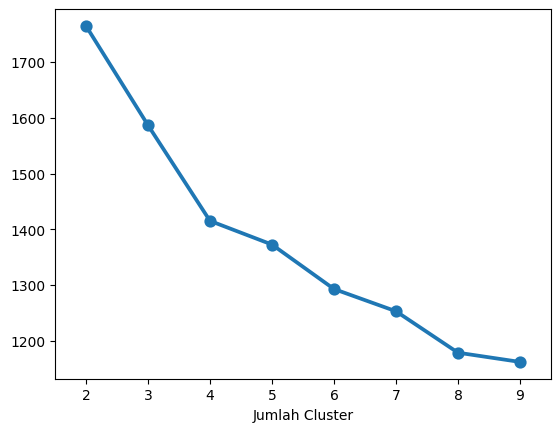

Jumlah klaster optimal = 4


In [ ]:
# Elbow Method
cost = {}
for k in range(2, 10):
    kproto = KPrototypes(n_clusters = k, init = 'Huang')
    kproto.fit_predict(df_np, categorical = categorical_idx)
    cost[k] = kproto.cost_

# Plot Elbow
sns.pointplot(x = list(cost.keys()), y = list(cost.values()))
plt.xlabel('Jumlah Cluster')
plt.show()

# Cari elbow dengan KneeLocator
kl = KneeLocator(list(cost.keys()), list(cost.values()), curve = 'convex', direction = 'decreasing')
optimal_k = kl.elbow
print("Jumlah klaster optimal =", optimal_k)

## MODELLING

In [ ]:
# Model
model = KPrototypes(n_clusters = optimal_k, init = 'Huang')
model.fit(df_np, categorical = categorical_idx)

KPrototypes(gamma=np.float64(0.07106965782223126), init='Huang',
            n_clusters=np.int64(4))

## ANALISIS KLASTER

In [ ]:
# Cluster centorid
print(model.cluster_centroids_)
# Cek iterasi cluster
print(model.n_iter_)
# Cek cost cluster
print(model.cost_)

[['0.31173798203909103' 'LAKI-LAKI' 'PELAJAR/MAHASISWA'
  'DIPLOMA IV/STRATA I' 'Akta Kelahiran']
 ['0.47965467722004973' 'LAKI-LAKI' 'KARYAWAN SWASTA' 'SLTA/SEDERAJAT'
  'Kartu Keluarga']
 ['0.4326769807782431' 'PEREMPUAN' 'KARYAWAN SWASTA'
  'DIPLOMA IV/STRATA I' 'Kartu Keluarga']
 ['0.4123491071772934' 'PEREMPUAN' 'MENGURUS RUMAH TANGGA'
  'SLTA/SEDERAJAT' 'Akta Kelahiran']]
4
1465.548995947107


In [ ]:
clusters = model.fit_predict(df_np, categorical = categorical_idx)
df_cluster = df.copy()
df_cluster['Cluster'] = clusters
df_cluster

,NAMA LAYANAN,KELURAHAN,JENIS KELAMIN,USIA,PEKERJAAN,PENDIDIKAN,KATEGORI LAYANAN,Cluster
0,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Sidotopo Wetan (1002),PEREMPUAN,23.0,PELAJAR/MAHASISWA,BELUM TAMAT SD/SEDERAJAT,Akta Kelahiran,1
1,Akta Kelahiran Sudah Memiliki NIK Anak Ayah da...,Tegalsari (1001),PEREMPUAN,26.0,PELAJAR/MAHASISWA,SLTP/SEDERAJAT,Akta Kelahiran,1
2,Keabsahan Akta Kelahiran (Pemilik dokumen SURA...,Rangkah (1005),PEREMPUAN,56.0,WIRASWASTA,SLTP/SEDERAJAT,Keabsahan,3
3,Pemutakhiran Biodata,Simomulyo (1005),LAKI-LAKI,21.0,BELUM/TIDAK BEKERJA,SLTP/SEDERAJAT,Biodata,2
5,SKTT OA (PEMBUATAN BARU),Babat Jerawat (1002),PEREMPUAN,29.0,KARYAWAN SWASTA,SLTA/SEDERAJAT,Layanan Orang Asing,1
...,...,...,...,...,...,...,...,...
16398,Pemutakhiran Biodata,Karah (1002),PEREMPUAN,55.0,PEGAWAI NEGERI SIPIL (PNS),DIPLOMA IV/STRATA I,Biodata,2
16399,Cetak Ulang KK Karena Rusak,Klampis Ngasem (1003),LAKI-LAKI,67.0,WIRASWASTA,SLTP/SEDERAJAT,Kartu Keluarga,0
16400,Legalisir Akta Kelahiran (Pemilik dokumen SURA...,Pegirian (1002),LAKI-LAKI,47.0,KARYAWAN SWASTA,SLTA/SEDERAJAT,Legalisir,0
16403,Pemutakhiran Biodata,Sawunggaling (1006),PEREMPUAN,31.0,KARYAWAN SWASTA,AKADEMI/DIPLOMA III/SARJANA MUDA,Biodata,2


In [ ]:
# Cluster
cluster_0 = df_cluster[df_cluster['Cluster'] == 0]
cluster_0

,NAMA LAYANAN,KELURAHAN,JENIS KELAMIN,USIA,PEKERJAAN,PENDIDIKAN,KATEGORI LAYANAN,Cluster
16,Kutipan Kedua Kelahiran Karena Hilang Domisili...,Wonokromo (1001),LAKI-LAKI,29.0,KARYAWAN SWASTA,SLTA/SEDERAJAT,Akta Kelahiran,0
19,SKTT OA (PEMBUATAN BARU),Kedungdoro (1003),LAKI-LAKI,34.0,KARYAWAN SWASTA,SLTA/SEDERAJAT,Layanan Orang Asing,0
22,Legalisir Akta Kelahiran (Pemilik dokumen SURA...,Keputih (1001),LAKI-LAKI,52.0,KARYAWAN SWASTA,DIPLOMA IV/STRATA I,Legalisir,0
23,Pindah Keluar Seluruh Anggota KK,Asem Rowo (1001),LAKI-LAKI,34.0,KARYAWAN SWASTA,DIPLOMA IV/STRATA I,Kartu Keluarga,0
24,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Bangkingan (1001),LAKI-LAKI,28.0,KARYAWAN SWASTA,SLTA/SEDERAJAT,Akta Kelahiran,0
...,...,...,...,...,...,...,...,...
16377,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Simokerto (1001),LAKI-LAKI,37.0,KARYAWAN SWASTA,TAMAT SD/SEDERAJAT,Akta Kelahiran,0
16393,Cetak Ulang KK Karena Rusak,Babat Jerawat (1002),LAKI-LAKI,41.0,NELAYAN/PERIKANAN,SLTA/SEDERAJAT,Kartu Keluarga,0
16397,Cetak Ulang KK Karena Rusak,Kedungdoro (1003),LAKI-LAKI,36.0,PELAJAR/MAHASISWA,SLTA/SEDERAJAT,Kartu Keluarga,0
16399,Cetak Ulang KK Karena Rusak,Klampis Ngasem (1003),LAKI-LAKI,67.0,WIRASWASTA,SLTP/SEDERAJAT,Kartu Keluarga,0


In [ ]:
# Cluster
cluster_1 = df_cluster[df_cluster['Cluster'] == 1]
cluster_1

,NAMA LAYANAN,KELURAHAN,JENIS KELAMIN,USIA,PEKERJAAN,PENDIDIKAN,KATEGORI LAYANAN,Cluster
0,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Sidotopo Wetan (1002),PEREMPUAN,23.0,PELAJAR/MAHASISWA,BELUM TAMAT SD/SEDERAJAT,Akta Kelahiran,1
1,Akta Kelahiran Sudah Memiliki NIK Anak Ayah da...,Tegalsari (1001),PEREMPUAN,26.0,PELAJAR/MAHASISWA,SLTP/SEDERAJAT,Akta Kelahiran,1
5,SKTT OA (PEMBUATAN BARU),Babat Jerawat (1002),PEREMPUAN,29.0,KARYAWAN SWASTA,SLTA/SEDERAJAT,Layanan Orang Asing,1
6,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Kebraon (1002),PEREMPUAN,34.0,KARYAWAN SWASTA,SLTA/SEDERAJAT,Akta Kelahiran,1
7,Akta Perkawinan + Cetak KK,Kedungdoro (1003),PEREMPUAN,28.0,PELAJAR/MAHASISWA,SLTP/SEDERAJAT,Akta Perkawinan,1
...,...,...,...,...,...,...,...,...
16389,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Sidotopo (1005),PEREMPUAN,32.0,KARYAWAN SWASTA,SLTA/SEDERAJAT,Akta Kelahiran,1
16391,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Morokrembangan (1005),PEREMPUAN,28.0,MENGURUS RUMAH TANGGA,TAMAT SD/SEDERAJAT,Akta Kelahiran,1
16392,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Nginden Jangkungan (1005),PEREMPUAN,26.0,GURU,DIPLOMA IV/STRATA I,Akta Kelahiran,1
16394,Akta Perkawinan + Cetak KK,Wiyung (1001),LAKI-LAKI,28.0,PELAJAR/MAHASISWA,SLTP/SEDERAJAT,Akta Perkawinan,1


In [ ]:
# Cluster
cluster_2 = df_cluster[df_cluster['Cluster'] == 2]
cluster_2

,NAMA LAYANAN,KELURAHAN,JENIS KELAMIN,USIA,PEKERJAAN,PENDIDIKAN,KATEGORI LAYANAN,Cluster
3,Pemutakhiran Biodata,Simomulyo (1005),LAKI-LAKI,21.0,BELUM/TIDAK BEKERJA,SLTP/SEDERAJAT,Biodata,2
8,Legalisir Akta Kelahiran (Pemilik dokumen SURA...,Pakis (1006),PEREMPUAN,36.0,KARYAWAN SWASTA,DIPLOMA IV/STRATA I,Legalisir,2
10,Akta Perkawinan + Cetak KK,Menur Pumpungan (1004),LAKI-LAKI,27.0,KARYAWAN SWASTA,DIPLOMA IV/STRATA I,Akta Perkawinan,2
13,Pemutakhiran Biodata,Lidah Kulon (1004),LAKI-LAKI,35.0,DOKTER,STRATA II,Biodata,2
17,AKTA KEMATIAN WARGA,Manyar Sabrangan (1002),PEREMPUAN,52.0,KARYAWAN SWASTA,DIPLOMA IV/STRATA I,Akta Kematian,2
...,...,...,...,...,...,...,...,...
16354,AKTA KEMATIAN WARGA TANPA NIK,Kertajaya (1004),PEREMPUAN,49.0,KARYAWAN SWASTA,DIPLOMA IV/STRATA I,Akta Kematian,2
16367,Pemutakhiran Biodata,Rangkah (1005),LAKI-LAKI,29.0,PEGAWAI NEGERI SIPIL (PNS),DIPLOMA IV/STRATA I,Biodata,2
16395,Akta Perkawinan + Cetak KK,Gading (1003),PEREMPUAN,27.0,APOTEKER,DIPLOMA IV/STRATA I,Akta Perkawinan,2
16398,Pemutakhiran Biodata,Karah (1002),PEREMPUAN,55.0,PEGAWAI NEGERI SIPIL (PNS),DIPLOMA IV/STRATA I,Biodata,2


In [ ]:
# Cluster
cluster_3 = df_cluster[df_cluster['Cluster'] == 3]
cluster_3

,NAMA LAYANAN,KELURAHAN,JENIS KELAMIN,USIA,PEKERJAAN,PENDIDIKAN,KATEGORI LAYANAN,Cluster
2,Keabsahan Akta Kelahiran (Pemilik dokumen SURA...,Rangkah (1005),PEREMPUAN,56.0,WIRASWASTA,SLTP/SEDERAJAT,Keabsahan,3
14,Akta Kelahiran Anak Kurang Dari 5 Tahun Anak A...,Rangkah (1005),PEREMPUAN,57.0,MENGURUS RUMAH TANGGA,SLTA/SEDERAJAT,Akta Kelahiran,3
15,Pemutakhiran Gelar,Babatan (1003),PEREMPUAN,61.0,PENSIUNAN,SLTA/SEDERAJAT,Biodata,3
20,Cetak Ulang KK Karena Rusak,Sidotopo (1005),PEREMPUAN,41.0,MENGURUS RUMAH TANGGA,SLTA/SEDERAJAT,Kartu Keluarga,3
21,Cetak Ulang KK Karena Rusak,Gunung Sari (1003),PEREMPUAN,47.0,MENGURUS RUMAH TANGGA,DIPLOMA IV/STRATA I,Kartu Keluarga,3
...,...,...,...,...,...,...,...,...
16371,Cetak Ulang KK Karena Rusak,Medokan Ayu (1006),PEREMPUAN,53.0,PELAJAR/MAHASISWA,DIPLOMA IV/STRATA I,Kartu Keluarga,3
16375,AKTA KEMATIAN WARGA,Pakis (1006),PEREMPUAN,51.0,KARYAWAN SWASTA,SLTA/SEDERAJAT,Akta Kematian,3
16376,AKTA KEMATIAN WARGA,Pacarkembang (1004),PEREMPUAN,61.0,MENGURUS RUMAH TANGGA,SLTA/SEDERAJAT,Akta Kematian,3
16390,AKTA KEMATIAN WARGA,Sawahan (1002),PEREMPUAN,49.0,WIRASWASTA,TAMAT SD/SEDERAJAT,Akta Kematian,3


In [ ]:
# Interpretasi cluster
df_cluster.groupby('Cluster').agg(
    {
        'KELURAHAN': lambda x: x.value_counts().index[0],
        'JENIS KELAMIN': lambda x: x.value_counts().index[0],
        'PEKERJAAN': lambda x: x.value_counts().index[0],
        'PENDIDIKAN': lambda x: x.value_counts().index[0],
        'KATEGORI LAYANAN': lambda x: x.value_counts().index[0],
        'USIA': 'mean'
    }
).reset_index()

,Cluster,KELURAHAN,JENIS KELAMIN,PEKERJAAN,PENDIDIKAN,KATEGORI LAYANAN,USIA
0,0,Wonokusumo (1003),LAKI-LAKI,KARYAWAN SWASTA,SLTA/SEDERAJAT,Kartu Keluarga,42.580637
1,1,Wonokusumo (1003),PEREMPUAN,PELAJAR/MAHASISWA,SLTA/SEDERAJAT,Akta Kelahiran,28.168247
2,2,Babatan (1003),PEREMPUAN,KARYAWAN SWASTA,DIPLOMA IV/STRATA I,Biodata,37.252980
3,3,Wonokusumo (1003),PEREMPUAN,MENGURUS RUMAH TANGGA,SLTA/SEDERAJAT,Kartu Keluarga,52.506587


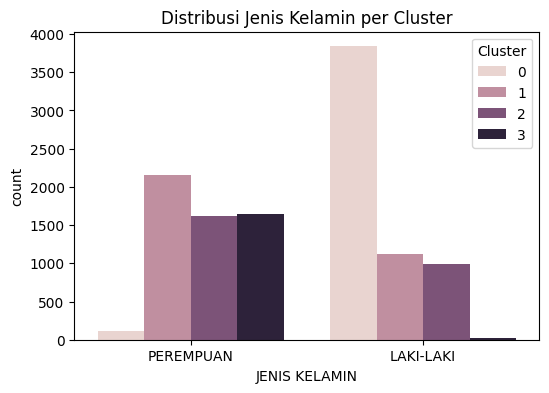

In [ ]:
plt.figure(figsize = (6, 4))
sns.countplot(data = df_cluster, x = 'JENIS KELAMIN', hue = 'Cluster')
plt.title('Distribusi Jenis Kelamin per Cluster')
plt.legend(title = 'Cluster')
plt.show()

In [ ]:
df_cluster.groupby('Cluster')['USIA'].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,3956.0,42.580637,11.636762,2.0,34.0,42.0,50.0,87.0
1,3269.0,28.168247,5.117872,4.0,25.0,28.0,31.0,52.0
2,2601.0,37.252980,8.886756,5.0,31.0,36.0,42.0,75.0
3,1670.0,52.506587,13.603770,23.0,43.0,52.0,62.0,92.0


In [ ]:
for cluster in sorted(df_cluster['Cluster'].unique()):
    print(f"\nTop layanan di Cluster {cluster}:")
    print(df_cluster[df_cluster['Cluster'] == cluster]['KATEGORI LAYANAN'].value_counts().head(5))


Top layanan di Cluster 0:
KATEGORI LAYANAN
Kartu Keluarga         1499
Akta Kelahiran          829
Akta Kematian           456
Biodata                 354
Layanan Orang Asing     235
Name: count, dtype: int64

Top layanan di Cluster 1:
KATEGORI LAYANAN
Akta Kelahiran     1461
Akta Perkawinan     453
Biodata             372
Kartu Keluarga      285
Akta Kematian       263
Name: count, dtype: int64

Top layanan di Cluster 2:
KATEGORI LAYANAN
Biodata            1185
Akta Kelahiran      435
Kartu Keluarga      208
Akta Kematian       202
Akta Perkawinan     171
Name: count, dtype: int64

Top layanan di Cluster 3:
KATEGORI LAYANAN
Kartu Keluarga         550
Akta Kematian          371
Akta Kelahiran         316
Biodata                142
Layanan Orang Asing     68
Name: count, dtype: int64


In [ ]:
for cluster in sorted(df_cluster['Cluster'].unique()):
    print(f"\nCluster {cluster}")
    top_5 = df_cluster[df_cluster['Cluster'] == cluster]['PEKERJAAN'].value_counts().head(5)
    print(top_5)


Cluster 0
PEKERJAAN
KARYAWAN SWASTA               2636
WIRASWASTA                     421
PELAJAR/MAHASISWA              277
BELUM/TIDAK BEKERJA            241
PEGAWAI NEGERI SIPIL (PNS)     127
Name: count, dtype: int64

Cluster 1
PEKERJAAN
PELAJAR/MAHASISWA        2154
BELUM/TIDAK BEKERJA       376
MENGURUS RUMAH TANGGA     304
KARYAWAN SWASTA           191
WIRASWASTA                113
Name: count, dtype: int64

Cluster 2
PEKERJAAN
KARYAWAN SWASTA          1499
PELAJAR/MAHASISWA         202
MENGURUS RUMAH TANGGA     154
WIRASWASTA                150
BELUM/TIDAK BEKERJA       132
Name: count, dtype: int64

Cluster 3
PEKERJAAN
MENGURUS RUMAH TANGGA         1285
KARYAWAN SWASTA                102
WIRASWASTA                      75
PEGAWAI NEGERI SIPIL (PNS)      54
BELUM/TIDAK BEKERJA             52
Name: count, dtype: int64


In [ ]:
for cluster in sorted(df_cluster['Cluster'].unique()):
    print(f"\nCluster {cluster}")
    top_5 = df_cluster[df_cluster['Cluster'] == cluster]['KELURAHAN'].value_counts().head(20)
    print(top_5)


Cluster 0
KELURAHAN
Wonokusumo (1003)              99
Ngagel Rejo (1004)             87
Tanah Kali Kedinding (1001)    86
Babatan (1003)                 84
Lontar (1004)                  82
Putat Jaya (1004)              76
Mojo (1002)                    71
Petemon (1001)                 69
Pakis (1006)                   68
Wonorejo (1005)                64
Medokan Ayu (1006)             61
Sidotopo Wetan (1002)          60
Morokrembangan (1005)          60
Tembok Dukuh (1005)            59
Ploso (1002)                   57
Simomulyo Baru (1006)          56
Kebraon (1002)                 56
Kapasmadya Baru (1007)         55
Kalirungkut (1001)             54
Gading (1003)                  50
Name: count, dtype: int64

Cluster 1
KELURAHAN
Wonokusumo (1003)              89
Tanah Kali Kedinding (1001)    84
Ngagel Rejo (1004)             71
Medokan Ayu (1006)             66
Sidotopo Wetan (1002)          62
Babatan (1003)                 55
Putat Jaya (1004)              53
Morokrembangan

In [ ]:
for cluster in sorted(df_cluster['Cluster'].unique()):
    print(f"\nCluster {cluster}")
    top_5 = df_cluster[df_cluster['Cluster'] == cluster]['PENDIDIKAN'].value_counts().head(5)
    print(top_5)


Cluster 0
PENDIDIKAN
SLTA/SEDERAJAT                      1974
DIPLOMA IV/STRATA I                  795
SLTP/SEDERAJAT                       357
TAMAT SD/SEDERAJAT                   296
AKADEMI/DIPLOMA III/SARJANA MUDA     171
Name: count, dtype: int64

Cluster 1
PENDIDIKAN
SLTA/SEDERAJAT              1270
SLTP/SEDERAJAT               624
TAMAT SD/SEDERAJAT           371
BELUM TAMAT SD/SEDERAJAT     368
DIPLOMA IV/STRATA I          284
Name: count, dtype: int64

Cluster 2
PENDIDIKAN
DIPLOMA IV/STRATA I                 1972
SLTA/SEDERAJAT                       136
AKADEMI/DIPLOMA III/SARJANA MUDA     135
STRATA II                            109
SLTP/SEDERAJAT                        91
Name: count, dtype: int64

Cluster 3
PENDIDIKAN
SLTA/SEDERAJAT                      813
TAMAT SD/SEDERAJAT                  302
SLTP/SEDERAJAT                      230
DIPLOMA IV/STRATA I                 167
AKADEMI/DIPLOMA III/SARJANA MUDA     63
Name: count, dtype: int64
